In [193]:
#Import scikit-learn dataset library
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

#Load dataset
cancer = datasets.load_breast_cancer()

In [195]:
# print the names of the 13 features
print("Features: ", cancer.feature_names)

# print the label type of cancer('malignant' 'benign')
print("Labels: ", cancer.target_names)

Features:  ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Labels:  ['malignant' 'benign']


In [197]:
# Import train_test_split function
from sklearn.model_selection import train_test_split

# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, test_size=0.3,random_state=109) # 70% training and 30% test

In [199]:
# Initialize Logistic Regression classifier
logreg = LogisticRegression(max_iter=10000)

In [201]:
# Define hyperparameter grid for tuning
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],  # Regularization parameter
    "solver": ["lbfgs", "liblinear"],  # Solvers
    "penalty": ["l2"],  # L2 regularization
}

In [203]:
# Train the best model on the full training set
best_logreg = grid_search.best_estimator_
best_logreg.fit(X_train, y_train)

LogisticRegression(C=10, max_iter=10000)

In [204]:
# Perform k-fold cross-validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=109)
cv_scores = cross_val_score(best_logreg, X_train, y_train, cv=kfold, scoring="accuracy")
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross-Validation Accuracy Scores: [0.95       0.9625     0.9375     0.93670886 0.96202532]
Mean CV Accuracy: 0.949746835443038


In [205]:
# Make predictions on the test set
y_pred = best_logreg.predict(X_test)

In [207]:
# Evaluate performance on the test set
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Calculate specificity (true negative rate)
specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])

# Print evaluation metrics for the test dataset
print("\nPerformance Metrics for Test Dataset:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Specificity: {specificity:.4f}")


Performance Metrics for Test Dataset:
Accuracy: 0.9708
Precision: 0.9813
Recall (Sensitivity): 0.9722
F1-score: 0.9767
Specificity: 0.9683



Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96        63
           1       0.98      0.97      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



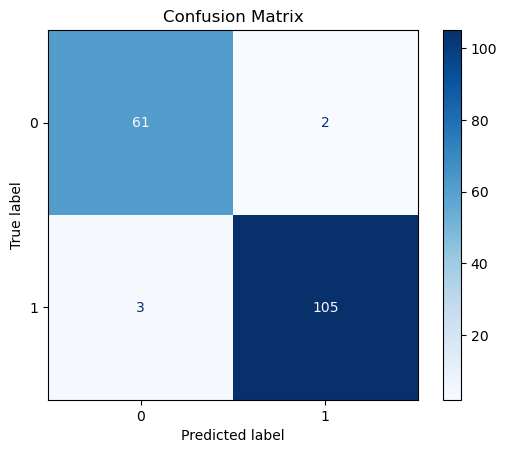

In [208]:
# Detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_logreg.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()